# Week 1 Workbook 1 Solutions: Naive Models

In any forecasting study the first thing you need to do is create a naive benchmark.  We can use naive benchmarks as simple methods for producing forecasting or as a way to check that the more complicated models we will use later the course are worth the effort to use/maintain.

🎓 **In this practical, we will apply our knowledge in**

* ✅ Creating baseline naive forecasts
* ✅ Performing a train-test split
* ✅ Using forecast error metrics MAE and MAPE to select the best method 
* ✅ Producing prediction intervals for naive methods
* ✅ Analysing prediction intervals using formal metrics as part of model comparison.
* 🎁 **Bonus**: visualising time series with `forecast-tools` 

---
**Before attempting the exercises, it is recommended that you watch the following code along tutorials that describes how to use python for basic forecasting**.

* **Reading time series data into pandas**:
    * Code along video (5 mins): https://bit.ly/pandas_ts
    * [Code along notebook](https://colab.research.google.com/github/health-data-science-OR/forecasting/blob/master/01_basics/01_code_along_notebooks/pandas_time_series.ipynb)
    
* **Benchmark models**:
    * Code along video (15 mins): https://bit.ly/benchmark_code_along
    * [Code along notebook](https://colab.research.google.com/github/health-data-science-OR/forecasting/blob/master/01_basics/01_code_along_notebooks/ca_benchmark_forecasts.ipynb)
    
---

## Standard Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy.typing import ArrayLike
import sys

## `Install forecast-tools`

In [2]:
# if running in Google Colab install forecast-tools
if 'google.colab' in sys.modules:
    !pip install forecast-tools

## `forecast-tools` imports

In [3]:
#baseline forecast methods
from forecast_tools.baseline import (
    Naive1, 
    SNaive,
    Drift,
    Average,
    baseline_estimators
)

from forecast_tools.metrics import(
    mean_absolute_percentage_error,
    mean_absolute_error,
    winkler_score,
    absolute_coverage_difference,
    coverage,
)

from forecast_tools.plotting import plot_time_series

## Helper functions

The naive forecasting methods generate forecasts and prediction intervals in a `np.ndarray`.  For convenience I have included two two helper functions to convert these arrary to a `pd.DataFrame` with a `DateTimeIndex`. This is helpful for plotting where the date is needed.

> 🎓 You are free to use these functions in your own work.

In [4]:
def preds_as_series(data: ArrayLike, preds: np.ndarray) -> pd.DataFrame:
    '''
    Helper function for plotting predictions.
    
    Converts a 1D numpy array of predictions to a 
    pandas.DataFrame with datetimeindex
    
    Parameters
    -----------
    data: arraylike
        The training data
    preds: np.array
        Vector of predictions 
    
    Returns:
    -------
    pandas.DataFrame
    '''
    start = pd.date_range(
        start=data.index.max(), 
        periods=2, 
        freq=data.index.freq
    ).max()
    
    idx = pd.date_range(start=start, periods=len(preds), freq=data.index.freq)
    return pd.DataFrame(preds, index=idx)

In [5]:
def intervals_as_dataframe(
    intervals: np.ndarray, 
    test: pd.DataFrame
) -> pd.DataFrame:
    '''
    Helper function for plotting predictions.
    
    Converts 2D numpy array containing prediction intervals to a 
    pandas.DataFrame with datetimeindex.

    Parameters:
    ----------
    intervals: np.ndarray 
        matrix of prediction intervals

    test: pd.DataFrame
        test in a dataframe format. This is passed to extract the datetimeindex
        to use in the new intervals dataframe.
    '''
    formatted_intervals = pd.DataFrame(
        intervals, 
        index=test.index, 
        columns=["lower", "upper"]
    )

    return formatted_intervals

## Exercise 1: Using Naive1 to forecast monthly outpatient appointments.

**Step 1: Import monthly outpatient appointments time series**  

This can be found in **"data/out_appoints_mth.csv"**
or 'https://raw.githubusercontent.com/health-data-science-OR/hpdm097-datasets/master/out_appoints_mth.csv'

* Hint: this is monthly data.  You can use the monthly Start ('MS') frequency

In [6]:
# your code here ...
url = 'https://raw.githubusercontent.com/health-data-science-OR/' \
        + 'hpdm097-datasets/master/out_appoints_mth.csv'

In [7]:
appoints = pd.read_csv(url, index_col='date', parse_dates=True, dayfirst=False)
appoints.index.freq = 'MS'

In [8]:
appoints.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 49 entries, 2014-04-01 to 2018-04-01
Freq: MS
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   out_apts  49 non-null     int64
dtypes: int64(1)
memory usage: 784.0 bytes


**Step 2 Plot the data**

In [9]:
# your code here ...

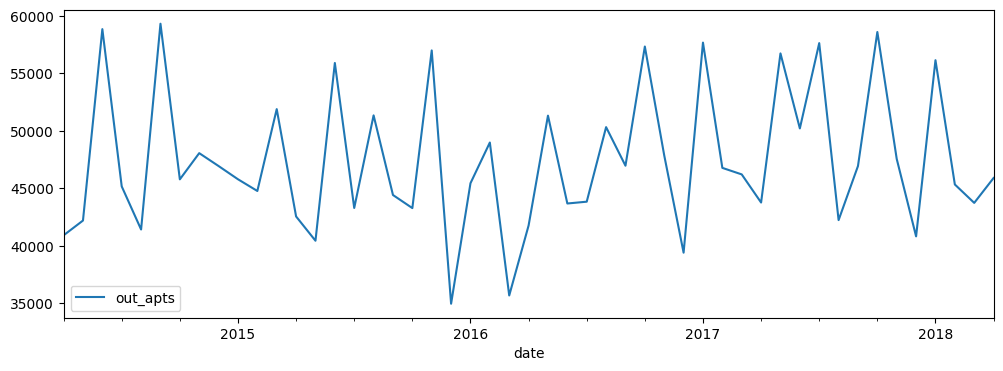

In [9]:
_ = appoints.plot(figsize=(12,4))

**Step 3: Create and fit Naive1 forecast model**

* Hint: you want to fit `appoints['out_apts']`

In [11]:
# your code here ...

In [10]:
nf1 = Naive1()
nf1.fit(appoints['out_apts'])

**Step 4: Plot the Naive1 fitted values**

All the baseline models have fitted values.  These are the in-sample prediction i.e. the predictions of the training data.

Once you have created and fitted a Naive1 model you can access the fitted values using the `.fittedvalues` property.  This returns a `DataFrame`.

Plot the fitted values against the observed data.

In [13]:
# your code here ...

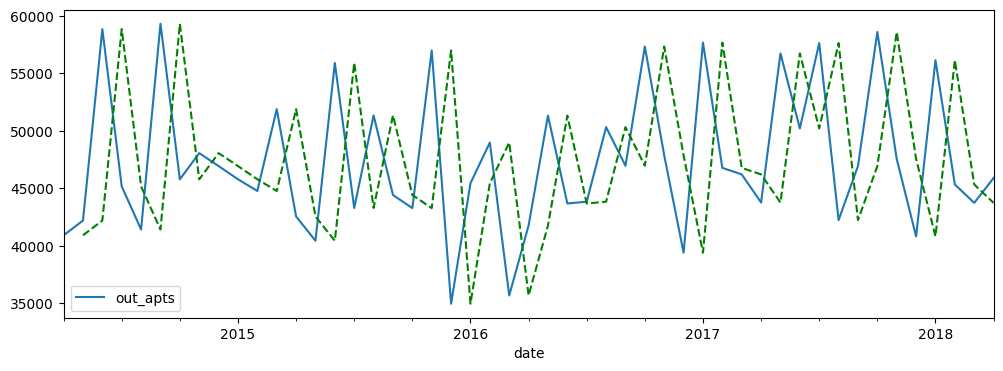

In [11]:
ax = appoints.plot(figsize=(12,4))
_ = nf1.fittedvalues.plot(ax=ax, color='green', linestyle='--')

**Step 5: Forecast the next 6 months**

After you have created a forecast plot the predictions.  

* Hint: use the `pred_as_series()` method to plot the predictions.  See the lecture notes for exampes of how to use it.

In [15]:
# your code here ...

In [12]:
preds = nf1.predict(horizon=6)

In [13]:
preds = preds_as_series(appoints, preds)

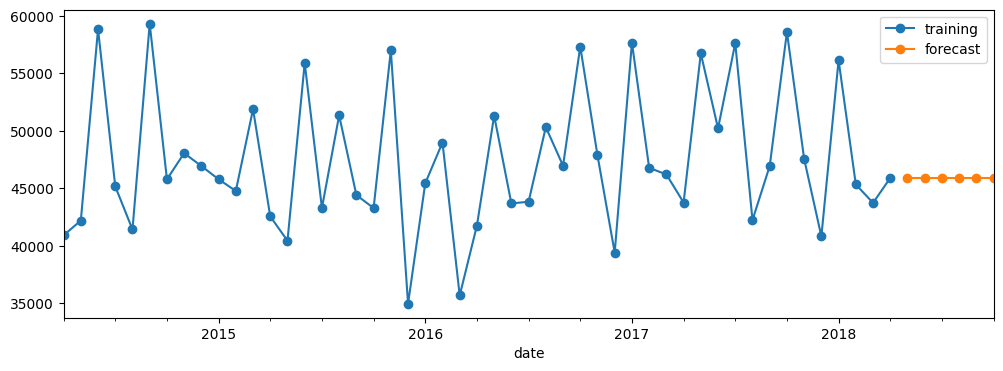

In [14]:
ax = appoints.plot(figsize=(12,4), marker='o')
preds.plot(ax=ax, marker='o')
_ = ax.legend(['training', 'forecast'])

## Exercise 2. Choose the best baseline forecast method for ED reattendances using point forecasts

**Step 1: Import emergency department reattendance data.**  

This is a time series from a hospital that measures the number of patients per month that have reattended an ED within 7 days of a previous attendance.

This can be found in **"ed_reattend.csv"**:  
'https://raw.githubusercontent.com/health-data-science-OR/hpdm097-datasets/master/ed_reattend.csv'

* Hint 1: The format of the 'date' column is in UK standard dd/mm/yyyy.  You will need to set the `dayfirst=True` of `pd.read_csv()` to make sure pandas interprets the dates correctly.

* Hint 2: The data is monthly and the dates are all the first day of the month.  This is called monthly start and its shorthand is 'MS'

In [19]:
# your code here ...
url = 'https://raw.githubusercontent.com/health-data-science-OR/' \
       + 'hpdm097-datasets/master/ed_reattend.csv'

In [20]:
reattends = pd.read_csv(url, index_col='date',  parse_dates=True, dayfirst=True)
reattends.index.freq = 'MS'

**Step 2: Perform a calender adjustment**

In [21]:
#your code here ...

In [22]:
reattend_rate = reattends['reattends'] / reattends.index.days_in_month

**Step 3: Perform a train-test split**

Create a train test split where you holdback the final 6 months of the data.

Remember to work with the calender adjusted data.

* Hint: The test set is the last 6 rows in your pandas DataFrame

In [23]:
# our code here ...

In [24]:
# train test split
train = reattend_rate.iloc[:-6]
test = reattend_rate.iloc[-6:]

In [25]:
train.shape

(37,)

In [26]:
test.shape

(6,)

**Step 4: Plot the TRAINING data**

Remember don't look at the test data just yet.  You don't want to bias your model selection process.

In [27]:
# your code here ...

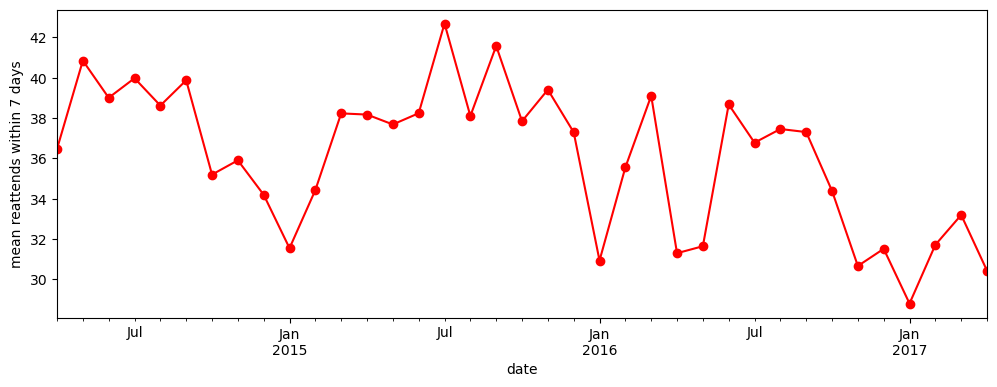

In [28]:
ax = train.plot(figsize=(12,4), color='red', marker='o', legend=False)
_ = ax.set_ylabel('mean reattends within 7 days')

**Step 5: Create and fit Naive1, and SNaive baseline models**

* Hint: Fit the TRAINING data.

In [29]:
# your code here ...

In [30]:
model_1 = Naive1()
model_2 = SNaive(12)

In [31]:
model_1.fit(train)
model_2.fit(train)

**Step 6: Use each model to predict 6 months ahead**

* Hint.  You need to store the prediction results so that later on you can calculate the forecast error.

In [32]:
# your code here ...

In [33]:
preds_naive1 = model_1.predict(horizon=6)
preds_snaive = model_2.predict(horizon=6)

**Step 7: Calculate the mean absolute error of each forecast method**
    
Based on the results which method would you choose?

In [34]:
# your code here ...

In [35]:
mae_naive1 = mean_absolute_error(y_true=test, y_pred=preds_naive1)
mae_snaive = mean_absolute_error(y_true=test, y_pred=preds_snaive)

print("Mean absolute error (MAE):")
print(f"Naive 1: {round(mae_naive1, 1)}")
print(f"SNaive: {round(mae_snaive, 1)}")

Mean absolute error (MAE):
Naive 1: 2.0
SNaive: 7.1


## Exercise 3: Evaluate prediction intervals

The evaluation of a forecasting model can be enhanced by analysing prediction intervals.  You can do this visually or if you are conducting a more rigourous analysis using formal interval scores.

**Step 1: Produce 80 and 95% prediction intervals for the model 1.**

To obtain the prediction intervals we need to set the `return_predict_int` parameters of the `predict` function to `True`. E.g. 

```python
preds_naive, intervals_naive = model_1.predict(
    horizon=6, 
    return_predict_int=True, 
    alpha=[0.2, 0.05]
)
```

The `alpha` parameter accepts a list that contains the 100(1-`alpha`) prediction interval requests. For example, [0.2, 0.05] returns arrary containing both 80% and 95% prediction intervals.

In [36]:
# your code here ...

In [37]:
preds_naive1, intervals_naive1 = model_1.predict(
    horizon=6, 
    return_predict_int=True, 
    alpha=[0.2, 0.05]
)

In [38]:
# the intervals are a multi-dimentional array. They can be tricky to understand.
intervals_naive1

[array([[26.19850969, 34.66815698],
        [24.4443883 , 36.42227837],
        [23.09840362, 37.76826305],
        [21.96368604, 38.90298062],
        [20.96397979, 39.90268688],
        [20.06017625, 40.80649041]]),
 array([[23.95672947, 36.9099372 ],
        [21.27403231, 39.59263436],
        [19.21552638, 41.65114029],
        [17.4801256 , 43.38654107],
        [15.95120683, 44.91545984],
        [14.5689586 , 46.29770807]])]

To help visualise the return values you can convert the arrays to `DataFrame` using the `intervals_as_dataframe` helper function from the top of the notebook.  

* This will print out the intervals in nicely formatted text.
* Remember that in healthcare we are often predicting numbers of people. So consider how many decimal places are useful.

> 💡 I've used a dictionary comprehension below to create the keys and `DataFrames` for the naive1 prediction intervals in one go.  Remember this is just a loop and the code is just converting `np.array` objects into `pd.DataFrame` objects to help us inspect the intervals. 

In [39]:
# cast intervals array to dataframes inside a dictionary with keys '80%', '95%'
alphas = [0.2, 0.05]

# Create dictionary mapping coverage (80%', '95%') to DataFrames
intervals_naive1_dict = {
    f'{1-alpha:.0%} PI': intervals_as_dataframe(interval, test)
    for alpha, interval in zip(alphas, intervals_naive1)
}

# take a look at the 80% prediction intervals - now nicely formatted.
intervals_naive1_dict["80% PI"].round(1)

,lower,upper
date,,
2017-05-01,26.2,34.7
2017-06-01,24.4,36.4
2017-07-01,23.1,37.8
2017-08-01,22.0,38.9
2017-09-01,21.0,39.9
2017-10-01,20.1,40.8


In [40]:
# and here are the 95% intervals
intervals_naive1_dict["95% PI"].round(1)

,lower,upper
date,,
2017-05-01,24.0,36.9
2017-06-01,21.3,39.6
2017-07-01,19.2,41.7
2017-08-01,17.5,43.4
2017-09-01,16.0,44.9
2017-10-01,14.6,46.3


**Step 2: Produce 80 and 95% prediction intervals for the model 2**

In [41]:
preds_snaive, intervals_snaive = model_2.predict(
    horizon=6, 
    return_predict_int=True, 
    alpha=[0.2, 0.05]
)

alphas = [0.2, 0.05]

# Create dictionary mapping coverage (80%', '95%') to DataFrames
intervals_snaive_dict = {
    f'{1-alpha:.0%} PI': intervals_as_dataframe(interval, test)
    for alpha, interval in zip(alphas, intervals_snaive)
}

# take a look at the 80% prediction intervals - now nicely formatted.
intervals_snaive_dict["80% PI"].round(1)

,lower,upper
date,,
2017-05-01,26.7,36.6
2017-06-01,33.7,43.6
2017-07-01,31.9,41.7
2017-08-01,32.5,42.4
2017-09-01,32.4,42.2
2017-10-01,29.5,39.3


In [42]:
intervals_snaive_dict["95% PI"].round(1)

,lower,upper
date,,
2017-05-01,24.1,39.2
2017-06-01,31.1,46.2
2017-07-01,29.2,44.3
2017-08-01,29.9,45.0
2017-09-01,29.8,44.8
2017-10-01,26.9,41.9


**Step 3: Visualise the prediction intervals for both models**

This is only practical when you have a small number of time series and models. 

You can create your own `matplotlib` functions for plotting. Alternatively for simple interactive plotting you could make use of the `forecast_tools.plotting.plot_time_series` function. It requires you to manipulate your data slightly:

```python
_ = plot_time_series(
    training_data = pd.DataFrame(train),
    test_data = pd.DataFrame(test),
    forecast = pd.DataFrame(preds_naive1, index=test.index),
    prediction_intervals = intervals_naive1_dict,
    y_axis_label="Reattendances",
)
```

**Important usage notes**:

* The function requires you to pass in the training, test, and forecast data in as a `pd.DataFrame`. Note I have converted the types here.

* We need to make that our forecasting `pd.DataFrame` has the same `DateTimeIndex` as test. i.e.

```python
forecast = pd.DataFrame(preds_naive1, index=test.index),
```

* The `prediction_intervals` parameter expects a dictionary object containing `pd.DataFrame` objects. We have already created this early to inspect prediction intervals.

💡 Does the shape of the prediction intervals alter your decision?

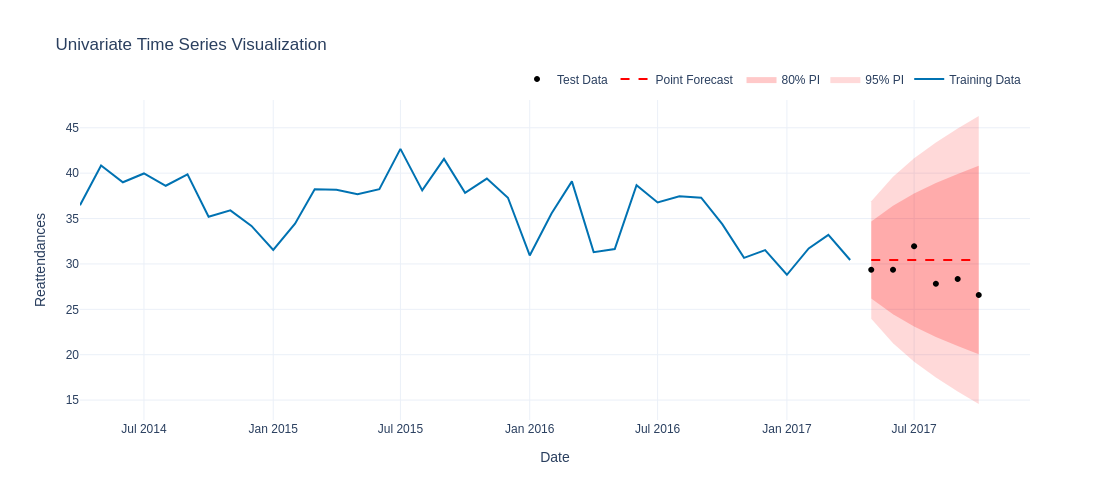

In [43]:
# model 1
_ = plot_time_series(
    training_data = pd.DataFrame(train),
    test_data = pd.DataFrame(test),
    forecast = pd.DataFrame(preds_naive1, index=test.index),
    prediction_intervals = intervals_naive1_dict,
    y_axis_label="Reattendances",
)

In [44]:
# model 2
_ = plot_time_series(
    training_data = pd.DataFrame(train),
    test_data = pd.DataFrame(test),
    forecast = pd.DataFrame(preds_snaive, index=test.index),
    prediction_intervals = intervals_snaive_dict,
    y_axis_label="Reattendances",
    color_scheme='green'
)

**Step 4: Calculate prediction interval scores for 80% intervals**

* Here we will calculate the Winkler score, absolute coverage difference, and empirical coverage
* Do the results alter your decision?
* Which measure(s) were the most useful for this time series?


💡 **In a formal lab report consider producing a formatted table all metrics (point forecasts and prediction intervals) using pandas.**

> Also see: `forecast-tools` [documentation](https://tommonks.github.io/forecast-tools/content/02a_coverage_metrics.html)

**Empirical Coverage**

A simple way providing a score to a prediction interval is to quantify its empirical coverage of a test set, i.e. the percentage of points that fall within the interval.  For a 80% interval you aims for 80% of the points to fall within it.

You can use the `coverage` function from `forecast_tools.metrics` (imported at top of notebook) to calculate it. E.g.

```python
cover_naive1 = coverage(y_true=test, pred_intervals=intervals_naive1[0])
```

Make sure you replace `test` and `intervals_naive1[0]` with the names of your variables.

In [45]:
# empirical coverage

cover_naive1 = coverage(y_true=test, pred_intervals=intervals_naive1[0])
cover_snaive = coverage(y_true=test, pred_intervals=intervals_snaive[0])

print("Empirical Coverage")
print(round(cover_naive1, 2))
print(round(cover_snaive, 2))

Empirical Coverage
1.0
0.33


**Absolute Coverage Difference (ACD)**

The absolute coverage difference is the absolute difference between empirical coverage and the target coverage level.

For example if the average coverage is 83% and the target is a 95% coverage then the absolute coverage difference is

$|0.83 - 0.95| = 0.12$

**Smaller ACD scores are better.**

Use the `forecast_tools.metrics.absolute_coverage_difference` function to calculate the ACD.

In [46]:
# absolute coverage difference
acd_naive1 = absolute_coverage_difference(
    y_true=test, 
    intervals=intervals_naive1[0],
    alpha=0.2

)
acd_snaive = absolute_coverage_difference(
    y_true=test, 
    intervals=intervals_snaive[0],
    alpha=0.2
)

print("Absolute Coverage Difference:")
print(round(acd_naive1, 2))
print(round(acd_snaive, 2))

Absolute Coverage Difference:
0.2
0.47


**Winkler score**

A Winkler score is the width of the prediction interval plus a penalty proportional to the deviation (above or below the interval) and 2/$\alpha$

The Winkler score is defined as

$$W_{\alpha,t} = \begin{cases}
  (u_{\alpha,t} - \ell_{\alpha,t}) + \frac{2}{\alpha} (\ell_{\alpha,t} - y_t) & \text{if } y_t < \ell_{\alpha,t} \\
  (u_{\alpha,t} - \ell_{\alpha,t})   & \text{if }  \ell_{\alpha,t} \le y_t \le u_{\alpha,t} \\
  (u_{\alpha,t} - \ell_{\alpha,t}) + \frac{2}{\alpha} (y_t - u_{\alpha,t}) & \text{if } y_t > u_{\alpha,t}.
  \end{cases}$$
  
  
Where 

* $u_{\alpha, t}$ is the upper prediction interval value for $\alpha$ and horizon $t$
* $l_{\alpha, t}$ is the lower prediction interval value for $\alpha$ and horizon $t$
* $y_t$ is the ground truth observation at horizon $t$

**smaller winkler scores are better!**

You can use `forecast_tools.metrics.winkler_score` to calculate it. For example:

```python
# test = test data
# intervals_naive1[0] = array of 80% prediction intervals
# alpha = 0.2 for a 80% prediction interval and 0.05 for a 95% prediction interval.
winkler_naive1 = winkler_score(
    y_true=test, 
    intervals=intervals_naive1[0], 
    alpha=0.2
)
```


In [47]:
# Winkler score

# Naive1
winkler_naive1 = winkler_score(
    y_true=test, 
    intervals=intervals_naive1[0], 
    alpha=0.2
)

# SNaive
winkler_snaive = winkler_score(
    y_true=test, 
    intervals=intervals_snaive[0], 
    alpha=0.2
)

print("Winker Score:")
print(f"Naive 1: {round(winkler_naive1, 2)}")
print(f"SNaive: {round(winkler_snaive, 2)}")

Winker Score:
Naive 1: 15.29
SNaive: 36.56


## End